In [ ]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for parent in v._parents: 
                edges.add((parent, v))
                build(parent)

    build(root)
    return nodes, edges


def draw_dot(root, format='svg', rankdir='LR'):
    assert rankdir in ['LR', 'TB']
    
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(
            name=str(id(n)),
            label="{ data %.4f | grad %.4f }" % (n.data, n.grad),
            shape='record'
        )

        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

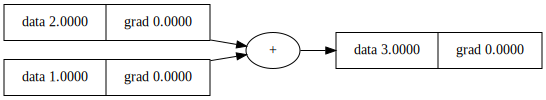

In [ ]:
import random
from value import Value

# (1 + 2) * 3
y = Value(1) + Value(2)
# k = Value(3) * y
# k.backward()

dot = draw_dot(y)
# dot = draw_dot(k)
dot